In [155]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



In [157]:
data = pd.read_excel("data/distance_vs_time.xlsx")


In [159]:
data.head()

,time_s,distance_cm,dist_uncertainity,time_uncertainity
0,0.6,59,15,0.05
1,1.2,132,15,0.05
2,1.8,191,15,0.05
3,2.4,235,15,0.05


The Beats per minute used is 100 and we used 4 koosh balls to mark the distance traveled by the car at a consequetive beat


# Error Analysis


The average reaction time of a human when for an expected event is around 0.15 sec.
Since the koosh balls were droped at estimated places and not the exact, the uncertainity is around 10 centimeter.
The truck also has some uncertainities as it isn't a point mass but deviate around 5 cm from the center.

In [164]:
tot_dist_uncertainity = 5 + 10
tot_time_uncertainity = 0.05
time_unit = "(seconds)"
distance_unit = "(centimeter)"

Text(0.5, 1.0, 'Position vs Time Scatter')

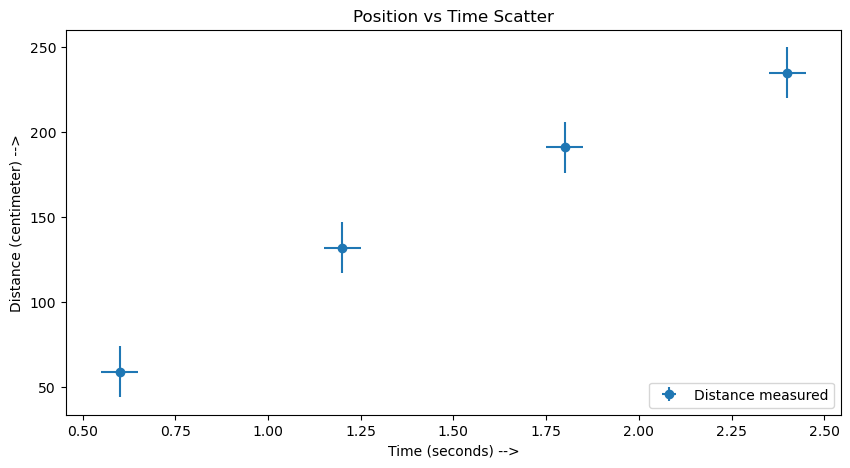

In [166]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(data['time_s'], data['distance_cm'], yerr=tot_dist_uncertainity, xerr=tot_time_uncertainity, fmt='o', label="Distance measured")
ax.set_xlabel(f"Time {time_unit} -->")
ax.set_ylabel(f"Distance {distance_unit} -->")
ax.legend(loc='lower right')
ax.set_title("Position vs Time Scatter")

# Generalizing the relationship between the position and time


To get a numerical value for velocity, we fit a straight line to each of the data sets. We use a linear model $$y = A + Bx$$

In [170]:
linear_model = lambda x, A, B: A*x + B

In [172]:
para, cov = curve_fit(linear_model, # linear model
                                  data["time_s"], # x-data
                                  data["distance_cm"], # y-data
                                  

In [223]:
initial_pos = para[1]
velocity = para[0]


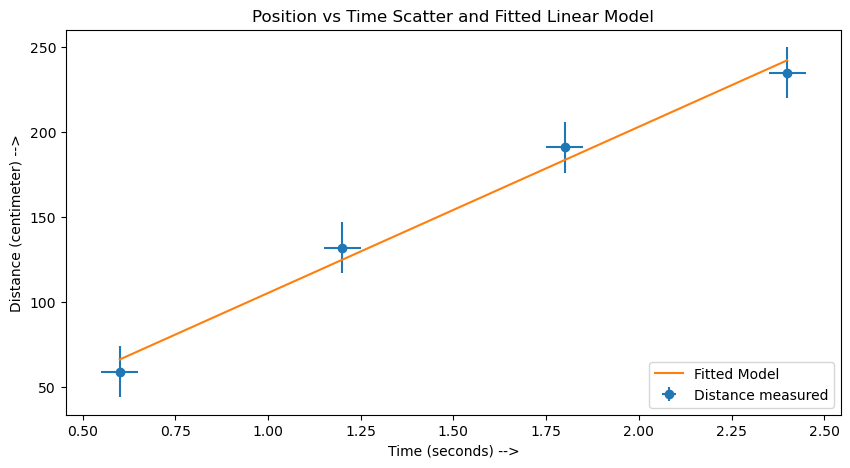

In [193]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(data['time_s'], data['distance_cm'], yerr=tot_dist_uncertainity, xerr=tot_time_uncertainity, fmt='o', label="Distance measured")
ax.set_xlabel(f"Time {time_unit} -->")
ax.set_ylabel(f"Distance {distance_unit} -->")
ax.set_title("Position vs Time Scatter and Fitted Linear Model")
time = np.linspace(min(data['time_s']), max(data['time_s']), 1000)
pos = linear_model(time, velocity, initial_pos)
ax.plot(time, pos, label="Fitted Model")
ax.legend(loc='lower right')

In [228]:
print(f"Velocity = {velocity}")
print(f"Velocity corrected to the right sig figs = {velocity:.1g}")

Velocity = 97.83333330385928
Velocity corrected to the right sig figs = 1e+02


Since our estimated velocity is 97.833-> cm/s but since our uncertainity is 15 cm we can round it to the correct number of significant digits. $$\boxed{v_{\text{Velocity}} = 100 \pm 15 \text{(cm/s)}}$$
